# Rotation Ciphers and Exactly How Broken They Are

Classical crypto on $\mathbb{Z}/26\mathbb{Z}$, with the damage quantified instead of asserted:

1. **ROT-$c$ (Caesar)** — encryption as modular addition; ROT13 as an involution
2. **Frequency analysis** — an autocracker that needs no key
3. **Entropy & redundancy** — English carries ~1.5 bits/letter but spends 4.7; the spare
   capacity is the attacker's budget
4. **Unicity distance** — Shannon's number: *how many ciphertext letters until the key is
   uniquely determined*. The "how broken is it" scoreboard, in characters
5. **Vigenère** — the polyalphabetic upgrade, broken anyway (index of coincidence + per-column Caesar)
6. **One-time pad** — the only entry with unicity distance $\infty$

Continues the crypto thread from the inner-products/ML-kernels/crypto commit.

In [1]:
import numpy as np
from collections import Counter

ALPHA = "abcdefghijklmnopqrstuvwxyz"
A2I = {ch: i for i, ch in enumerate(ALPHA)}

# standard English letter frequencies (percent)
ENGLISH_FREQ = dict(zip(ALPHA, [
    8.17, 1.49, 2.78, 4.25, 12.70, 2.23, 2.02, 6.09, 6.97, 0.15, 0.77, 4.03,
    2.41, 6.75, 7.51, 1.93, 0.10, 5.99, 6.33, 9.06, 2.76, 0.98, 2.36, 0.15,
    1.97, 0.07]))
ENGLISH_P = np.array([ENGLISH_FREQ[c] for c in ALPHA]) / 100.0

def clean(text):
    # keep letters only, lowercase -- the classical-cipher alphabet
    return "".join(ch for ch in text.lower() if ch in A2I)

def rot(text, c):
    # ROT-c: encryption IS modular arithmetic, m -> m + c (mod 26)
    if not isinstance(c, int):
        raise TypeError(f"shift c must be an int, got {type(c).__name__}")
    return "".join(ALPHA[(A2I[ch] + c) % 26] for ch in clean(text))

PLAIN = clean('''
The separation vector points from the source to the field point and every
Coulomb integral in this book is a convolution against one over that distance
squared. The divergence of the unit radial field over r squared vanishes at
every point where it is defined and yet the flux through any sphere about the
origin is four pi, so the entire divergence hides inside a delta function at
the one point the naive calculation missed. This is Gauss law for a point
charge. In the Lorenz gauge the scalar and vector potentials obey the
inhomogeneous wave equation with the charge and current densities as sources,
and the whole of electrodynamics reduces to solving that single equation for a
specified source. Rapidity adds where velocity saturates, and the boost matrix
is the hyperbolic twin of the rotation matrix, preserving the Minkowski form
exactly as a rotation preserves the Euclidean dot product. The phase of an
optical field lost to square law detection can be recovered when dispersion
provides diversity, which is the working principle of this repository.
''')
print(f"plaintext: {len(PLAIN)} letters")
print(PLAIN[:70], "...")

plaintext: 875 letters
theseparationvectorpointsfromthesourcetothefieldpointandeverycoulombin ...


## §1 ROT-$c$: encryption as addition in $\mathbb{Z}/26\mathbb{Z}$

$E_c(m) = m + c \pmod{26}$, $D_c = E_{-c} = E_{26-c}$. The key space is all of 25 keys.
ROT13 is its own inverse because $13 + 13 \equiv 0 \pmod{26}$ — an involution, which is why
Usenet used it as a spoiler veil rather than security.

In [2]:
CIPHER = rot(PLAIN, 7)                       # the secret shift nobody told the attacker
print("ciphertext:", CIPHER[:70], "...")

# ROT13 is an involution: applying it twice is the identity
sample = "thequickbrownfox"
assert rot(rot(sample, 13), 13) == sample
print("rot13(rot13(x)) == x  -- involution, since 13+13 = 0 mod 26")

# decryption = encryption with the negative key
assert rot(CIPHER, -7) == PLAIN == rot(CIPHER, 19)
print("rot(c=-7) == rot(c=19) recovers the plaintext: keys live in Z/26Z")

ciphertext: aolzlwhyhapvucljavywvpuazmyvtaolzvbyjlavaolmplskwvpuahuklclyfjvbsvtipu ...
rot13(rot13(x)) == x  -- involution, since 13+13 = 0 mod 26
rot(c=-7) == rot(c=19) recovers the plaintext: keys live in Z/26Z


## §2 The autocracker: $\chi^2$ against English

A shift permutes the letter histogram without changing its *shape*. Slide the ciphertext
histogram through all 26 shifts and score each against English frequencies with
$\chi^2 = \sum_i (o_i - e_i)^2/e_i$; the true shift snaps into place. No key, no brain required —
which is the point: the *language* leaks, not the math.

recovered shift: 7 (truth: 7)  -> 'theseparationvectorpointsfromthesourceto...'


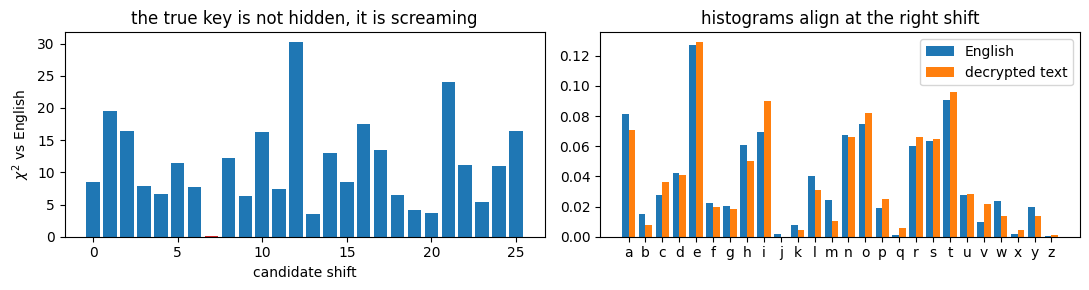

In [3]:
def letter_freqs(text):
    n = len(text)
    counts = Counter(text)
    return np.array([counts.get(c, 0) / n for c in ALPHA])

def crack_rot(cipher):
    # try all 26 shifts, return (best_shift, chi2 scores)
    cipher = clean(cipher)
    if not cipher:
        raise ValueError("ciphertext contains no letters")
    scores = []
    for c in range(26):
        obs = letter_freqs(rot(cipher, -c))
        scores.append(np.sum((obs - ENGLISH_P)**2 / ENGLISH_P))
    return int(np.argmin(scores)), np.array(scores)

best, scores = crack_rot(CIPHER)
print(f"recovered shift: {best} (truth: 7)  -> '{rot(CIPHER, -best)[:40]}...'")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].bar(range(26), scores, color=["C3" if i == best else "C0" for i in range(26)])
axes[0].set_xlabel("candidate shift"); axes[0].set_ylabel(r"$\chi^2$ vs English")
axes[0].set_title("the true key is not hidden, it is screaming")
w = 0.4
axes[1].bar(np.arange(26)-w/2, ENGLISH_P, w, label="English")
axes[1].bar(np.arange(26)+w/2, letter_freqs(rot(CIPHER, -best)), w, label="decrypted text")
axes[1].set_xticks(range(26)); axes[1].set_xticklabels(list(ALPHA))
axes[1].legend(); axes[1].set_title("histograms align at the right shift")
plt.tight_layout(); plt.show()

## §3 The spare capacity: entropy and redundancy of English

A 26-letter alphabet could carry $\log_2 26 = 4.70$ bits/letter. Measured unigram entropy of
English is $\approx 4.1$–$4.2$; with context (digrams, words, grammar) Shannon's experiments put
the true rate near $1.3$–$1.5$ bits/letter. The difference,

$$D = \log_2 26 - H_\text{lang} \approx 3.2\ \text{bits/letter},$$

is **redundancy** — structure the language spends on being decodable by humans. Every redundant
bit is information an attacker can use to reject wrong keys. Compression before encryption
shrinks exactly this attack surface.

In [4]:
def H(p):
    # Shannon entropy in bits, ignoring zero bins
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

H_uniform = np.log2(26)
H_unigram_std = H(ENGLISH_P)
H_unigram_here = H(letter_freqs(PLAIN))
H_true = 1.5                                     # Shannon's experimental estimate

print(f"capacity  log2(26)          : {H_uniform:.3f} bits/letter")
print(f"unigram H (reference table) : {H_unigram_std:.3f} bits/letter")
print(f"unigram H (this plaintext)  : {H_unigram_here:.3f} bits/letter")
print(f"true rate (Shannon, approx) : {H_true:.1f}   bits/letter")
D = H_uniform - H_true
print(f"redundancy D = log2(26) - H : {D:.2f} bits/letter  <- the attacker's budget")

capacity  log2(26)          : 4.700 bits/letter
unigram H (reference table) : 4.176 bits/letter
unigram H (this plaintext)  : 4.132 bits/letter
true rate (Shannon, approx) : 1.5   bits/letter
redundancy D = log2(26) - H : 3.20 bits/letter  <- the attacker's budget


## §4 Unicity distance: "how broken" as a number of characters

Shannon (1949): spurious keys die off once the redundancy collected from $n$ ciphertext letters
exceeds the key entropy. The crossover,

$$U = \frac{H(K)}{D},$$

is the **unicity distance**: beyond $\sim U$ ciphertext letters, only one key yields sensible
English — the cipher is information-theoretically dead, brute force is mere bookkeeping.

In [5]:
import math

ciphers = [
    ("ROT-c (Caesar)",        math.log2(26),            "26 keys"),
    ("random substitution",   math.log2(math.factorial(26)), "26! keys"),
    ("Vigenere, key len 5",   5*math.log2(26),          "26^5 keys"),
    ("Vigenere, key len 20",  20*math.log2(26),         "26^20 keys"),
    ("one-time pad",          float("inf"),             "key as long as the message"),
]
print(f"{'cipher':<24}{'H(K) bits':>11}{'unicity U (letters)':>22}   keyspace")
for name, hk, ks in ciphers:
    U = hk / D if math.isfinite(hk) else float("inf")
    print(f"{name:<24}{hk:>11.1f}{U:>22.1f}   {ks}")
print()
print("Caesar: ~1.5 letters of ciphertext already pin the key. Even the 26! keyspace")
print("of a substitution cipher (88 bits, 'bigger than AES-64') dies in ~28 letters --")
print("keyspace size is NOT security when the plaintext has spare structure.")

cipher                    H(K) bits   unicity U (letters)   keyspace
ROT-c (Caesar)                  4.7                   1.5   26 keys
random substitution            88.4                  27.6   26! keys
Vigenere, key len 5            23.5                   7.3   26^5 keys
Vigenere, key len 20           94.0                  29.4   26^20 keys
one-time pad                    inf                   inf   key as long as the message

Caesar: ~1.5 letters of ciphertext already pin the key. Even the 26! keyspace
of a substitution cipher (88 bits, 'bigger than AES-64') dies in ~28 letters --
keyspace size is NOT security when the plaintext has spare structure.


## §5 Vigenère: the "unbreakable" upgrade, broken on schedule

Key = a repeating word; letter $i$ gets shift $k_{i \bmod L}$. Flattens the single histogram,
which bought it three centuries of false confidence. Two-step kill:

1. **Key length** via the index of coincidence $IC = \sum_i p_i^2$: English text has
   $IC \approx 0.066$, uniform noise $0.038$. Slicing the ciphertext every $L$-th letter shows
   English-like $IC$ only at the true $L$.
2. Each slice is then a plain Caesar — §2's cracker finishes the job, letter by letter of the key.

vigenere ciphertext: klksrgexagzstvrtxurcfmttfwvumgyiyohigktbklkfvvpjpbzrzaauibee ...
IC plain = 0.0676, IC vigenere = 0.0454, uniform = 0.0385   <- single histogram flattened
key length by IC: 5 (truth: 5); high-IC candidates [np.int64(5), np.int64(10)] are L and its multiples
recovered key: 'regan' (truth: 'regan')
plaintext fully recovered.


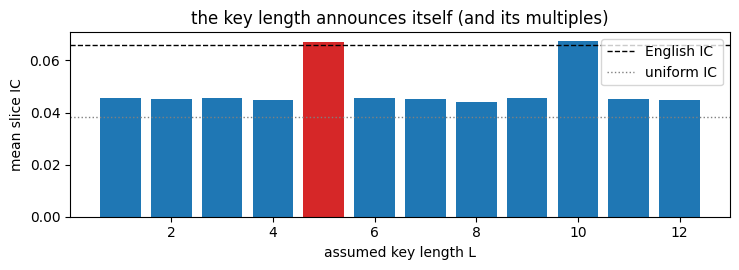

In [6]:
def vigenere(text, key, sign=+1):
    text, key = clean(text), clean(key)
    if not key:
        raise ValueError("key must contain at least one letter")
    return "".join(ALPHA[(A2I[ch] + sign*A2I[key[i % len(key)]]) % 26]
                   for i, ch in enumerate(text))

KEY = "regan"
VCIPHER = vigenere(PLAIN, KEY)
print("vigenere ciphertext:", VCIPHER[:60], "...")

def ic(text):
    # index of coincidence: probability two random letters match
    n = len(text)
    counts = np.array([text.count(c) for c in ALPHA])
    return float(np.sum(counts*(counts-1)) / (n*(n-1)))

print(f"IC plain = {ic(PLAIN):.4f}, IC vigenere = {ic(VCIPHER):.4f}, "
      f"uniform = {1/26:.4f}   <- single histogram flattened")

# step 1: key length = SMALLEST L whose slices look like English
# (multiples of the true L also score high, so argmax alone overshoots)
ics = []
for L in range(1, 13):
    ics.append(np.mean([ic(VCIPHER[s::L]) for s in range(L)]))
ics = np.array(ics)
candidates = np.flatnonzero(ics > 0.060) + 1
L_best = int(candidates[0]) if len(candidates) else int(np.argmax(ics)) + 1
print(f"key length by IC: {L_best} (truth: {len(KEY)}); "
      f"high-IC candidates {list(candidates)} are L and its multiples")

# step 2: crack each slice as a Caesar
recovered = "".join(ALPHA[crack_rot(VCIPHER[s::L_best])[0]] for s in range(L_best))
print(f"recovered key: '{recovered}' (truth: '{KEY}')")
assert vigenere(VCIPHER, recovered, sign=-1) == PLAIN
print("plaintext fully recovered.")

plt.figure(figsize=(7.5, 2.8))
plt.bar(range(1, 13), ics, color=["C3" if L == L_best else "C0" for L in range(1, 13)])
plt.axhline(0.066, ls="--", lw=1, color="k", label="English IC")
plt.axhline(1/26, ls=":", lw=1, color="gray", label="uniform IC")
plt.xlabel("assumed key length L"); plt.ylabel("mean slice IC")
plt.legend(); plt.title("the key length announces itself (and its multiples)")
plt.tight_layout(); plt.show()

## §6 One-time pad: unicity distance $\infty$

Key as long as the message, used once: every plaintext of the same length is *equally consistent*
with the ciphertext, so collecting more ciphertext earns the attacker nothing. Perfect secrecy
(Shannon 1949) — bought at the price of key logistics, which is the problem all of modern
cryptography (and QKD) is actually about.

In [ ]:
rng = np.random.default_rng(2026)
pad = rng.integers(0, 26, size=len(PLAIN))
otp_cipher = "".join(ALPHA[(A2I[ch] + int(k)) % 26] for ch, k in zip(PLAIN, pad))

# the same ciphertext 'decrypts' to ANY message of equal length under some pad:
fake = clean("the rogue wave monitor flagged nothing unusual today")
prefix = otp_cipher[:len(fake)]
fake_pad = [(A2I[c] - A2I[m]) % 26 for c, m in zip(prefix, fake)]
print("decrypted with the TRUE pad :", "".join(
    ALPHA[(A2I[c] - int(k)) % 26] for c, k in zip(otp_cipher, pad))[:46], "...")
print("decrypted with a FORGED pad :", "".join(
    ALPHA[(A2I[c] - k) % 26] for c, k in zip(prefix, fake_pad))[:46], "...")
print()
print("Both pads are equally plausible a priori -> the ciphertext proves nothing.")

# frequency analysis sees only noise:
print(f"IC of OTP ciphertext: {ic(otp_cipher):.4f} (uniform = {1/26:.4f}) -- nothing to grab")

decrypted with the TRUE pad : theseparationvectorpointsfromthesourcetothefie ...
decrypted with a FORGED pad : theroguewavemonitorflaggednothingunusualtoday ...

Both pads are equally plausible a priori -> the ciphertext proves nothing.
IC of OTP ciphertext: 0.0384 (uniform = 0.0385) -- nothing to grab


: 

## §7 Scoreboard and repo connections

| cipher | key entropy | unicity | verdict |
|---|---|---|---|
| ROT-$c$ | 4.7 bits | ~1.5 letters | broken by one word |
| substitution | 88 bits | ~28 letters | big keyspace, dead anyway |
| Vigenère ($L{=}5$) | 23.5 bits | ~7 letters | broken on schedule (§5 did it) |
| one-time pad | $=$ message | $\infty$ | the only survivor |

The through-line to this repo: **structure is what attackers (and algorithms) exploit.** Frequency
analysis recovers a hidden shift from statistical structure exactly the way TD-GS recovers hidden
*phase* from intensity structure — both invert a lossy map by leaning on redundancy (English
statistics there, dispersion diversity here; recall the GS convergence rule that near-zero
diversity $|D| < 5000$ fails like a too-short ciphertext). And the unicity distance is the same
information-budget bookkeeping as channel capacity in the signal-loss notebook: bits available vs
bits required.